
# Fitting Attenuated RHESSI Spectra


Fitting attenuated RHESSI Spectra

This is looking at the M9 class flare observed by RHESSI from [Knuth+Glesener 2020](https://iopscience.iop.org/article/10.3847/1538-4357/abb779).

We perform spectroscopy on the interval where the thick attenuator is inserted.

 Systematic error is important to add to RHESSI data so that the minimizer has some wiggle room.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from parfive import Downloader

import astropy.time as atime

from sunkit_spex.extern import rhessi
from sunkit_spex.legacy.fitting import fitter

Download the example data



In [2]:
# dl = Downloader()
# base_url = "https://homepages.dias.ie/smaloney/sunkit-spex/rhessi/"
# file_names = ["rhessi-2011-jul-stixbins-spec.fits", "rhessi-2011-jul-stixbins-srm.fits"]

# for fname in file_names:
#     dl.enqueue_file(base_url + fname, path="data/")
# files = dl.download()

Load in the spectrum and SRM, notice the warning about attenuator changes!



In [3]:
rl = rhessi.RhessiLoader(
    spectrum_fn="data/rhessi-2011-jul-stixbins-spec.fits",
    srm_fn="data/rhessi-2011-jul-stixbins-srm.fits",
)

/Users/iain/github/sunkit-spex/sunkit_spex/extern/rhessi.py:196: UserWarning: 
do not update event times to (2011-07-30T01:50:00.000, 2011-07-30T02:30:00.000): covers attenuator state change. Don't trust this fit!
  warnings.warn(


Notice there is no warning when the fit interval doesn't cover an attenuator change!



In [4]:
rl.update_event_times(atime.Time("2011-07-30T02:08:20"), atime.Time("2011-07-30T02:10:20"))
end_background_time = "2011-07-30T01:56:00"
start_background_time = "2011-07-30T01:54:00"
rl.update_background_times(atime.Time(start_background_time), atime.Time(end_background_time))

Notice there is no warning when the fit interval doesn't cover an attenuator change!



<Axes: title={'center': 'RHESSI Lightcurve'}, xlabel='Time (Start Time: 2011-07-30T01:50:00.000)', ylabel='Counts s$^{-1}$'>

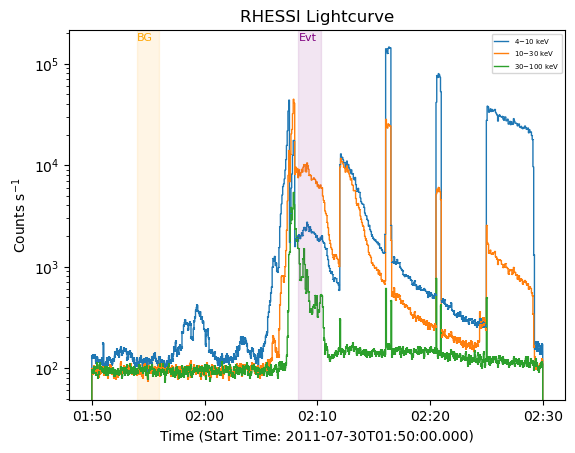

In [5]:
plt.figure()
rl.lightcurve(energy_ranges=[[4, 10], [10, 30], [30, 100]])

Add systematic error before passing to the fitter object

Uniform 10%



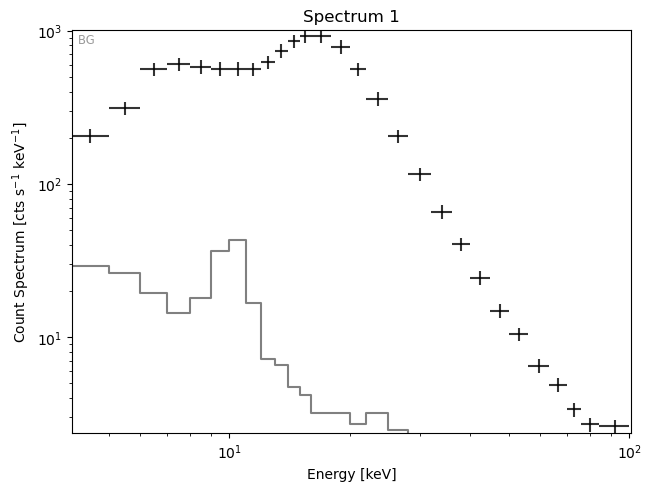

In [6]:
rl.systematic_error = 0.1

ss = fitter.Fitter(rl)
ss.energy_fitting_range = [5, 70]

plt.figure(layout="constrained")
axs, *_ = ss.plot()
_ = axs[0].set(xscale="log")

Define a custom model to and add to fitter.



In [7]:
def double_thick(electron_flux, low_index, break_energy, up_index, low_cutoff, up_cutoff, energies=None):
    from sunkit_spex.legacy.emission import bremsstrahlung_thick_target  # noqa: PLC0415

    mids = np.mean(energies, axis=1)
    flux = bremsstrahlung_thick_target(
        photon_energies=mids,
        p=low_index,
        eebrk=break_energy,
        q=up_index,
        eelow=low_cutoff,
        eehigh=up_cutoff,
    )

    # scale to good units
    return 1e35 * electron_flux * flux


ss.add_photon_model(double_thick, overwrite=True)

2026-07-16T22:49:51Z INFO sunkit_spex.legacy.fitting.fitter 801: Model double_thick added.


Prepare fit



In [8]:
ss.loglikelihood = "chi2"
ss.model = "f_vth + double_thick"

th_params = [
    "T1_spectrum1",
    "EM1_spectrum1",
]
nth_params = [
    "electron_flux1_spectrum1",
    "low_index1_spectrum1",
    "up_index1_spectrum1",
    "break_energy1_spectrum1",
    "low_cutoff1_spectrum1",
    "up_cutoff1_spectrum1",
]

ss.params["T1_spectrum1"] = ["free", 20, (5, 100)]
ss.params["EM1_spectrum1"] = ["free", 5000, (500, 100000)]

ss.params["electron_flux1_spectrum1"] = ["free", 10, (1, 50)]
ss.params["low_index1_spectrum1"] = ["free", 5, (1, 20)]
ss.params["up_index1_spectrum1"] = ["free", 5, (1, 20)]

ss.params["break_energy1_spectrum1"] = ["free", 40, (40, 100)]
ss.params["low_cutoff1_spectrum1"] = ["free", 20, (5, 39)]
ss.params["up_cutoff1_spectrum1"] = ["frozen", 500, (5, 1000)]

Fit the spectrum only varying the thermal params vary first



In [9]:
for p in th_params:
    ss.params[p] = "free"
for p in nth_params:
    ss.params[p] = "frozen"

_ = ss.fit()

Fit the spectrum only varying the non-thermal params vary first



In [10]:
for p in th_params:
    ss.params[p] = "frozen"
for p in nth_params:
    ss.params[p] = "free"

_ = ss.fit()

All params are free to vary



In [11]:
for p in th_params + nth_params:
    ss.params[p] = "free"

_ = ss.fit()

Plot



[None]

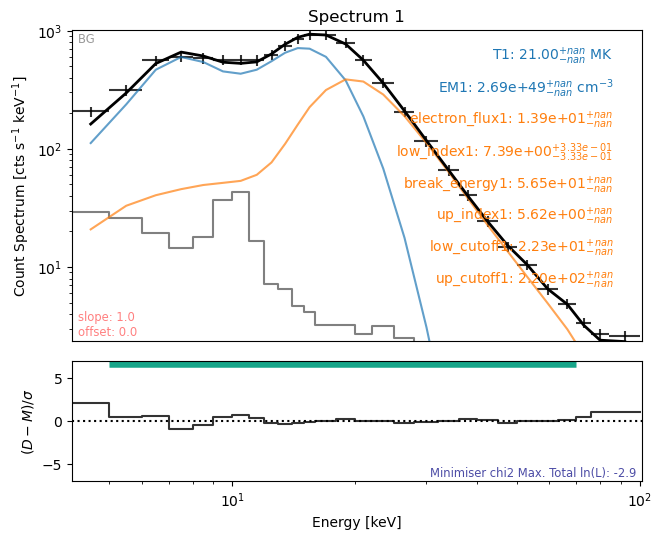

In [12]:
plt.figure(layout="constrained")
ss.plot()
plt.gca().set(xscale="log")

MCM (uncomment to run)



In [13]:
# ss.run_mcmc()